In [1]:
%matplotlib inline
import emcee
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as pl
from matplotlib.ticker import MaxNLocator
import scipy.integrate as integrate
import scipy.linalg as linalg
from multiprocessing.pool import ThreadPool
import os
from getdist import plots, MCSamples
import getdist, IPython
from scipy.integrate import quad
from scipy.special import gamma

global argsortz

os.environ["OMP_NUM_THREADS"] = "1"

pl.rcParams.update({
    "text.usetex": True,                # Usa o motor LaTeX para escrever tudo
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 16,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 14,              # Tamanho da legenda
    "xtick.labelsize": 12,              # Tamanho dos números no eixo X
    "ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

In [2]:
snnamei,zsni,mBi,smBi = np.genfromtxt("data/pantheon_full.txt", unpack=True)
snnamei,zsni,mui,smui = np.genfromtxt("data/pantheon_fullSorted.txt", unpack=True)
covsysraw = np.genfromtxt("data/pantheon_sys_full.txt", unpack=True)

nsn = len(snnamei)
argsortz = np.argsort(zsni)

In [7]:
c = 299792.458#km/s
wr = 9.2364e-5
wb = .0493
over = 1.25 # aumentando as incertezas em 25%

In [8]:
covsyspanth = np.zeros((nsn,nsn))
k = 0
for i in range(nsn):
    for j in range(nsn):
        covsyspanth[i,j] = covsysraw[k]
        k=k+1

covstatpanth = np.diag(smBi**2)
covpanth = covstatpanth + covsyspanth

covpanthsort = np.zeros((nsn,nsn))
for i in range(nsn):
    for j in range(nsn):
        covpanthsort[i,j] = (over**2)*covpanth[argsortz[i],argsortz[j]]

invcovsort = linalg.inv(covpanthsort)

In [5]:
#E(z)^2
def Ez2(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    return wm*(1+z)**3+(1-wm-wl)*(1+z)**2+wl

#E(z)^(-1)
def Ez_1(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    return 1./np.sqrt(wm*(1+z)**3+(1-wm-wl)*(1+z)**2+wl)

def odesys(y, z, pars):
    dydz = Ez_1(z,pars)
    return dydz

def solsys(y0, z, pars):
    return integrate.odeint(odesys, y0, z, args=(pars,), atol=1e-6)

#Distancia comovel de linha-de-visada adimensional (=dc/dH)
def Dcmodel(z,pars):
    y0 = 0.
    z = np.append([0.],z)
    sol = solsys(y0, z, pars)[:,0]
    sol = np.delete(sol,0)
    return sol

#Distancia comovel transversal adimensional (=dm/dH)
def Dmmodel(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    wk = 1. - wm - wl
    Dcm = Dcmodel(z,pars)
    if wk < 0:
        return np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return Dcm

def Dlmodel(z,pars):
    return (1+z)*Dmmodel(z,pars)

#Distancia comovel transversal in Mpc
def dmmodel(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    dH = c/H0
    wk = 1. - wm - wl
    Dcm = Dcmodel(z,pars)
    if wk < 0:
        return dH*np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return dH*np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return dH*Dcm

def dlmodel(z,pars):
    return (1+z)*dmmodel(z,pars)

In [6]:
#Distribution funcion for chi2
def chiDist(chi, n):
    return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

#Calculate cdf for chiDist
def chiCDF(x, n):
    res = np.zeros_like(x)
    for i, val in enumerate(x):
        y, err = quad(chiDist, 0, val, args=(n))
        res[i]=y
    return res

#Plot chi2 cdf
def plotChiDist(chimin, par, name=0):
    n = ndata - par
    chi = np.linspace(0, 2.5, 500)
    chiv = np.full((500), chimin/n)
    hv = chiDist2(chi, n)
    cdf = chiCDF(chi, n)
    y = np.linspace(0, 1.8, 500)
    
    pl.plot(chi, hv, label=r"$h _{\nu}$")
    pl.plot(chiv, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(np.round(chimin/n, 3)))
    pl.plot(chi, cdf, '--', label="cdf")
    
    pl.xticks(np.arange(0.0, 2.51, 0.5))
    pl.yticks(np.arange(0.0, 1.76, 0.25))
    pl.axis((0, 2.5, 0, 1.75))
    pl.grid(linestyle='-.', linewidth='0.5')
    pl.minorticks_on()
    
    pl.ylabel(r'$h_{\nu}$')
    pl.xlabel(r'$\chi _{\nu} ^{2}$')
    pl.legend(loc='best')
   
    if not name == 0:
        pl.savefig('fig/'+name+'.pdf')
    
    pl.show()

def best_par(samples):
    return np.mean(samples,axis=0)

def chi2_reduzido(samples, freef, flat, par, name=0):
    chi2mC = chi2Hz(free_par(best_par(samples), freef=freef, flat=flat))
    chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata-len(par)), args=(ndata-len(par)))
    plotChiDist(chi2mC, len(par), ndata, name=name)
    print(f'Probabilidade = {chivCperc*100}%')
    print(f'chi2v = {chi2mC/(ndata-len(par))}')
    print(f'chi2v mais provável = {1 - 2/(ndata-len(par))}')

In [10]:
def chi2snproj1(theta):
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    SA  = np.sum(invcovsort)
    Sr  = np.sum(np.dot(dmu.T,invcovsort))
    Srr = np.dot(np.dot(dmu.T,invcovsort),dmu)
    return Srr - Sr**2./SA

def chi2snproj(theta):
    H0, wm, wl, f = theta
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    invcovcorr = invcovsort/f**2
    SA  = np.sum(invcovcorr)
    Sr  = np.sum(np.dot(dmu.T,invcovcorr))
    Srr = np.dot(np.dot(dmu.T,invcovcorr),dmu)
    return Srr - Sr**2./SA

def lnprior1(theta):
    H0, wm, wl = theta
    if 0.0 < wm < 3.0 and 50. < H0 < 100. and -1.0 < wl < 3.0:
        return 0.0    #flat prior
    return -np.inf

def lnlike1(theta):
    chi2 = chi2snproj1(theta)
    return -0.5*chi2
 
def lnprob1(theta):
    lp = lnprior1(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike1(theta)

def lnprior(theta):
    H0, wm, wl, f = theta
    if 0.0 < wm < 3.0 and 50. < H0 < 100. and -1.0 < wl < 3.0 and .1 < f < 5:
        return 0.0    #flat prior
    return -np.inf

ndata = len(invcovsort)

def lnlike(theta):
    H0, wm, wl, f = theta
    return -.5*(chi2snproj(theta))-ndata*np.log(f)
 
def lnprob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta)

In [11]:
# Find the maximum likelihood value.
def find_bestfit(lnlike,par_ml):#,data):
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda *args: -2 * lnlike(*args)
    result = op.minimize(chi2, par_ml)#, args=data)
    if not result['success']:
        result = op.minimize(chi2, par_ml,method='Nelder-Mead',options={'maxiter': 10000})#, args=data
    par_ml = result["x"]
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    #ndof = len(data[0])-ndim
    #print('chi2red =',result['fun']/ndof)
    #print(result)
    t2 = time.time()
    print("tempo total: {0:5.3f} seg".format(t2-t1))
    return result

def run_emcee(par_ml,nwalkers,lnprob,ainput,nstep):
    # Set up the sampler.
    ndim = len(par_ml)
    pos = [par_ml + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    #sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput, threads=threadsin)#args=data,
    #sampler.run_mcmc(pos, nstep, progress=True);
    
    with ThreadPool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput, pool=pool)
        #start = time.time()
        sampler.run_mcmc(pos, nstep, progress=True)
        #end = time.time()
        #multi_time = end - start
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    #print("Multiprocessing took {0:.1f} seconds".format(multi_time))
    #print("{0:.1f} times faster than serial".format(serial_time / multi_time))
    return sampler

def plot_chains(sampler,par_ml,parlabtex):
    ndim = len(par_ml)
    pl.clf()
    fig, axes = pl.subplots(ndim, 1, sharex=True, figsize=(8, 9))
    for i in range(ndim):
        axes[i].plot(sampler.chain[:, :, i].T, color="k", alpha=0.4)
        axes[i].yaxis.set_major_locator(MaxNLocator(5))
        axes[i].axhline(par_ml[i], color="#888888", lw=2)
        axes[i].set_ylabel(parlabtex[i])
        
    axes[ndim-1].set_xlabel("step number")
    
    fig.tight_layout(h_pad=0.0)
    pl.show()

def tira_burnin(sampler,burnin,ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples

def burninthin(sampler,tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

def MC_result(samples, par_ml, parnames):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865], axis=0)[0]
    par_valp = np.percentile(samples, [84.135], axis=0)[0]
    par_valm2 = np.percentile(samples, [2.275013194800002], axis=0)[0]
    par_valp2 = np.percentile(samples, [97.7249868052], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    par_sigm2 = par_mean - par_valm2
    par_sigp2 = par_valp2 - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} +{3:5.5f} -{4:5.5f} -{5:5.5f} (median: {6:5.5f}, ml: {7:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigp2[i],par_sigm[i],par_sigm2[i],par_median[i],par_ml[i]))

In [12]:
par_ml  = [69.1929957609451,0.2480895086492853, 0.6862431649000225, 1.1]
par_ml1 = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndim = len(par_ml)
prefix = 'LcdmPanthCovCorr'
nstep = 3500
nstep1 = 3500
parlabels = ["H_0",r"\Omega_m", r"\Omega_\Lambda", 'f']#Latex sem $$
parlabtex = ["$H_0$",r"$\Omega_m$", r"$\Omega_\Lambda$", '$f$']#Latex com $$
parnames = ['H0','wm','wl','f']
parlabels1 = ["H_0",r"\Omega_m", r"\Omega_\Lambda"]#Latex sem $$
parlabtex1 = ["$H_0$",r"$\Omega_m$", r"$\Omega_\Lambda$"]#Latex com $$
parnames1 = ['H0','wm','wl']

In [13]:
result1 = find_bestfit(lnprob1,par_ml1)
print(result1,'\n')
par_ml1 = result1["x"]
result = find_bestfit(lnprob,par_ml)
print(result,'\n')
par_ml = result["x"]

Maximum likelihood result:
H0  =  69.1929957609451
wm  =  0.3478207763173116
wl  =  0.8294115022190459
chi2min = 735.7524168007076
tempo total: 0.442 seg
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 735.7524168007076
        x: [ 6.919e+01  3.478e-01  8.294e-01]
      nit: 7
      jac: [ 0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[ 1.000e+00  0.000e+00  0.000e+00]
            [ 0.000e+00  1.751e-04 -5.433e-05]
            [ 0.000e+00 -5.433e-05  1.877e-04]]
     nfev: 68
     njev: 17 



/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Maximum likelihood result:
H0  =  62.34251128054075
wm  =  0.3478358191445783
wl  =  0.8294894310021903
f  =  0.8378870598730338
chi2min = 677.27503541857
tempo total: 3.203 seg
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 677.27503541857
             x: [ 6.234e+01  3.478e-01  8.295e-01  8.379e-01]
           nit: 113
          nfev: 216
 final_simplex: (array([[ 6.234e+01,  3.478e-01,  8.295e-01,  8.379e-01],
                       [ 6.234e+01,  3.478e-01,  8.295e-01,  8.379e-01],
                       ...,
                       [ 6.234e+01,  3.478e-01,  8.295e-01,  8.379e-01],
                       [ 6.234e+01,  3.478e-01,  8.295e-01,  8.379e-01]],
                      shape=(5, 4)), array([ 6.773e+02,  6.773e+02,  6.773e+02,  6.773e+02,
                        6.773e+02])) 



In [14]:
sampler1 = run_emcee(par_ml1,100,lnprob1,2.0,nstep1)

100%|███████████████████████████████████████| 3500/3500 [13:38<00:00,  4.27it/s]

Acceptance fraction: [0.59171429 0.59657143 0.58942857 0.58857143 0.60971429 0.60057143
 0.59228571 0.59257143 0.62114286 0.584      0.61085714 0.57714286
 0.59314286 0.60657143 0.60342857 0.61942857 0.59285714 0.58942857
 0.62171429 0.60485714 0.60771429 0.59142857 0.59514286 0.60114286
 0.57942857 0.60942857 0.59485714 0.61228571 0.59542857 0.60485714
 0.60742857 0.62828571 0.59028571 0.60542857 0.59542857 0.59085714
 0.60742857 0.58685714 0.592      0.59228571 0.60314286 0.6
 0.62371429 0.60171429 0.58257143 0.59628571 0.61228571 0.61
 0.62171429 0.59514286 0.59714286 0.604      0.62085714 0.60714286
 0.62057143 0.61142857 0.612      0.61171429 0.59114286 0.60942857
 0.59857143 0.60171429 0.57914286 0.62714286 0.59028571 0.58657143
 0.61085714 0.59771429 0.596      0.58628571 0.59371429 0.598
 0.612      0.58657143 0.60542857 0.622      0.59142857 0.59542857
 0.60457143 0.59457143 0.60971429 0.59542857 0.59342857 0.61285714
 0.622      0.60971429 0.59028571 0.59171429 0.588      0.5

In [15]:
tau1 = sampler1.get_autocorr_time()
print(tau1)
tau1max = np.amax(tau1)
r = nstep1/tau1max
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

samples1 = burninthin(sampler1,tau1)

[45.63092762 37.34070488 37.83139033]
76.70236356484209
Convergiu! :)
(18900, 3)


In [16]:
MC_result(samples1,par_ml1, parnames1)
wm = 0.34477 +0.04587 +0.09009 -0.04576 -0.09439 (median: 0.34547, ml: 0.00000)
wl = 0.82289 +0.08403 +0.16400 -0.08514 -0.17357 (median: 0.82486, ml: 0.00000)

MCMC result:
H0 = 75.37823 +16.90567 +23.51452 -17.18019 -24.13009 (median: 75.75959, ml: 69.19300)
wm = 0.34411 +0.05472 +0.10621 -0.05503 -0.11592 (median: 0.34618, ml: 0.34782)
wl = 0.81955 +0.10073 +0.19392 -0.10104 -0.21276 (median: 0.82239, ml: 0.82941)


In [17]:
gsamples1 = MCSamples(samples=samples1,names=parnames1,labels=parlabels1)
gsamples1.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


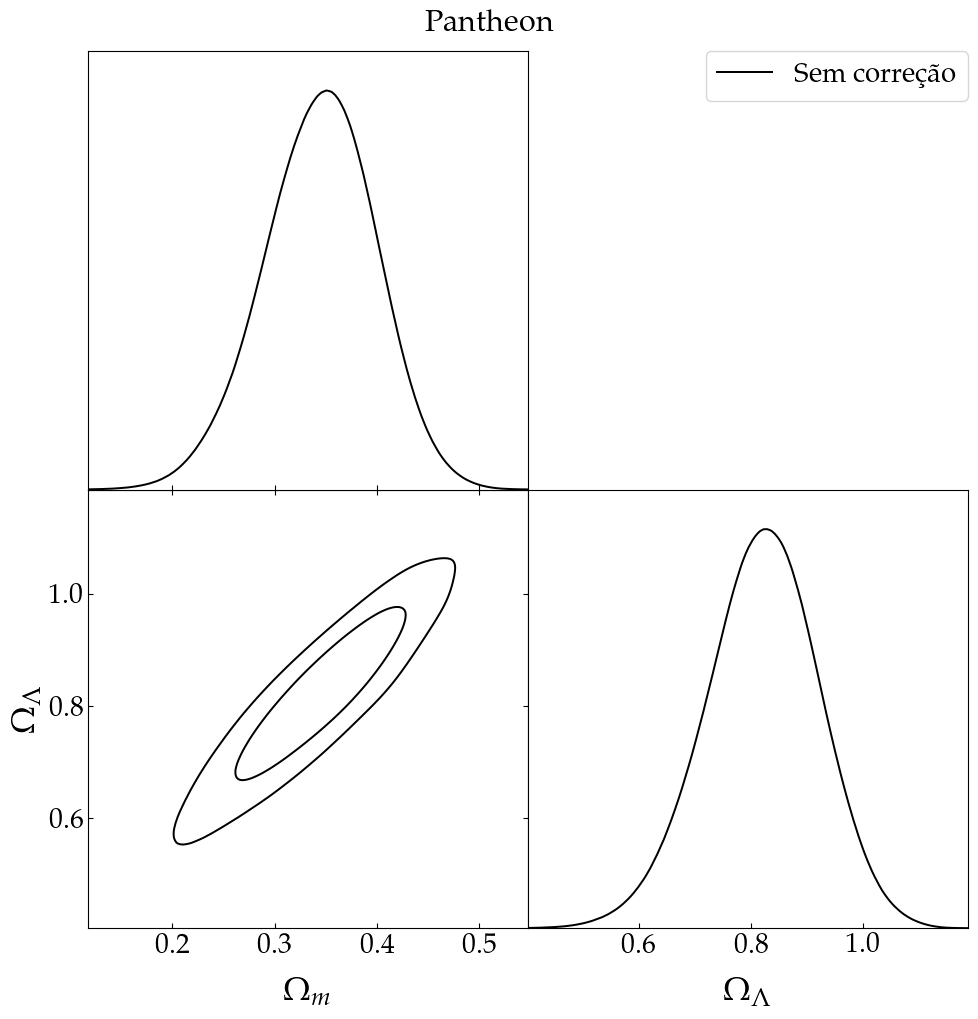

In [19]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamples1], ('wm', 'wl'), filled=False,legend_labels=['Sem correção'])
g.fig.suptitle(r"Pantheon", fontsize=22, y=1.02)
g.export('fig/Pantheon-no_f.pdf')
pl.show()

In [20]:
sampler = run_emcee(par_ml,100,lnprob,2.0,nstep)

100%|███████████████████████████████████████| 3500/3500 [24:59<00:00,  2.33it/s]

Acceptance fraction: [0.55028571 0.54485714 0.52171429 0.54257143 0.53571429 0.54457143
 0.52942857 0.54514286 0.54371429 0.53571429 0.56085714 0.544
 0.53657143 0.55114286 0.55571429 0.57057143 0.54857143 0.55514286
 0.54714286 0.54885714 0.556      0.53485714 0.54942857 0.55771429
 0.54342857 0.552      0.55085714 0.54942857 0.54114286 0.56085714
 0.54028571 0.55742857 0.54742857 0.574      0.554      0.54485714
 0.55228571 0.53657143 0.53942857 0.51685714 0.56       0.55114286
 0.55942857 0.53314286 0.54485714 0.538      0.54942857 0.53942857
 0.55571429 0.54628571 0.56057143 0.53628571 0.566      0.54685714
 0.558      0.562      0.56028571 0.55257143 0.558      0.54057143
 0.56457143 0.51657143 0.56885714 0.55314286 0.544      0.56085714
 0.55371429 0.54514286 0.55171429 0.55171429 0.55828571 0.55114286
 0.56457143 0.53771429 0.53028571 0.55885714 0.55628571 0.54171429
 0.56171429 0.54514286 0.55828571 0.546      0.53142857 0.57685714
 0.55628571 0.54828571 0.52885714 0.54342857 0

In [21]:
tau = sampler.get_autocorr_time(tol=0)
print(tau)
taumax = np.amax(tau)
r = nstep/taumax
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

samples = burninthin(sampler,tau)

[58.60972279 45.71412942 47.18128166 49.18043226]
59.7170543232416
Convergiu! :)
(15300, 4)


In [22]:
MC_result(samples, par_ml, parnames)

MCMC result:
H0 = 74.83018 +17.14699 +24.04560 -16.99022 -23.76043 (median: 74.64934, ml: 62.34251)
wm = 0.34477 +0.04587 +0.09009 -0.04576 -0.09439 (median: 0.34547, ml: 0.34784)
wl = 0.82289 +0.08403 +0.16400 -0.08514 -0.17357 (median: 0.82486, ml: 0.82949)
f = 0.83978 +0.01851 +0.03830 -0.01840 -0.03602 (median: 0.83953, ml: 0.83789)


In [23]:
gsamples = MCSamples(samples=samples,names=parnames,labels=parlabels)
gsamples.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


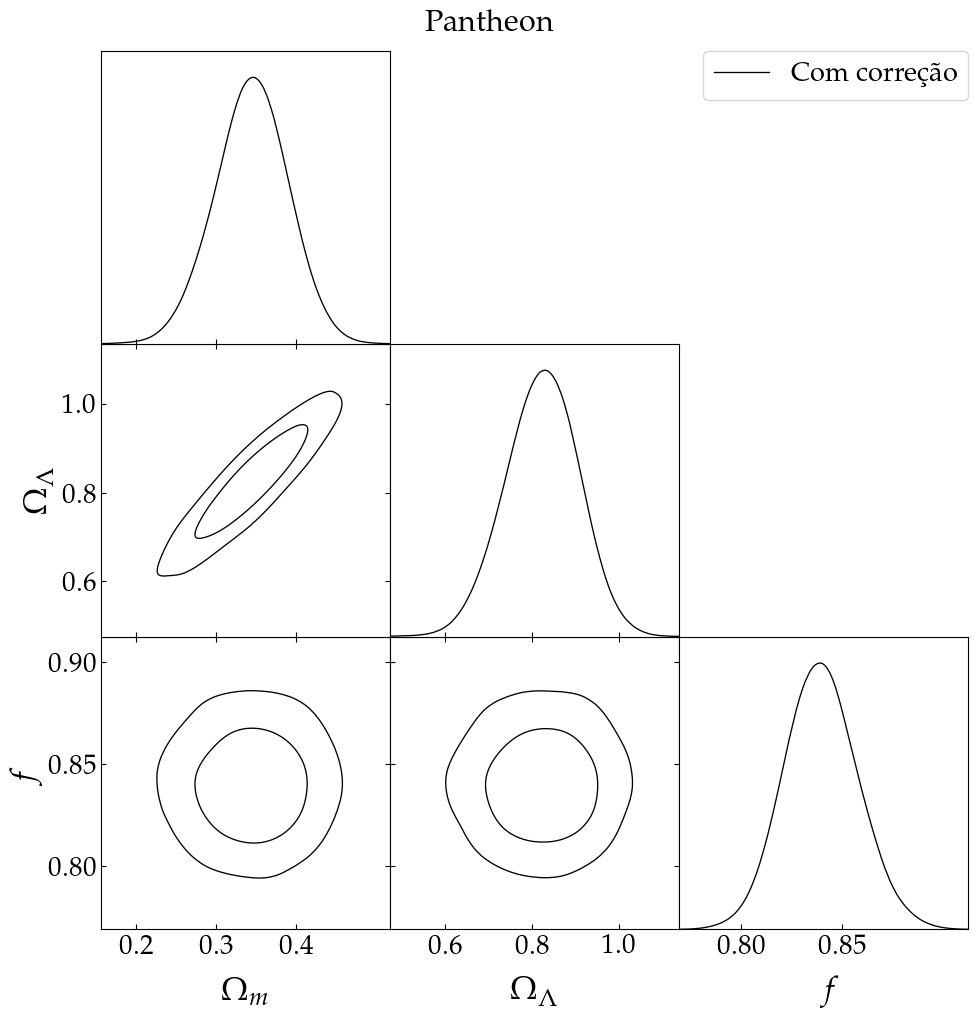

In [26]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamples], ('wm', 'wl', 'f'), filled=False,legend_labels=['Com correção'])
g.fig.suptitle(r"Pantheon", fontsize=22, y=1.02)
g.export('fig/Pantheon-f.pdf')
pl.show()

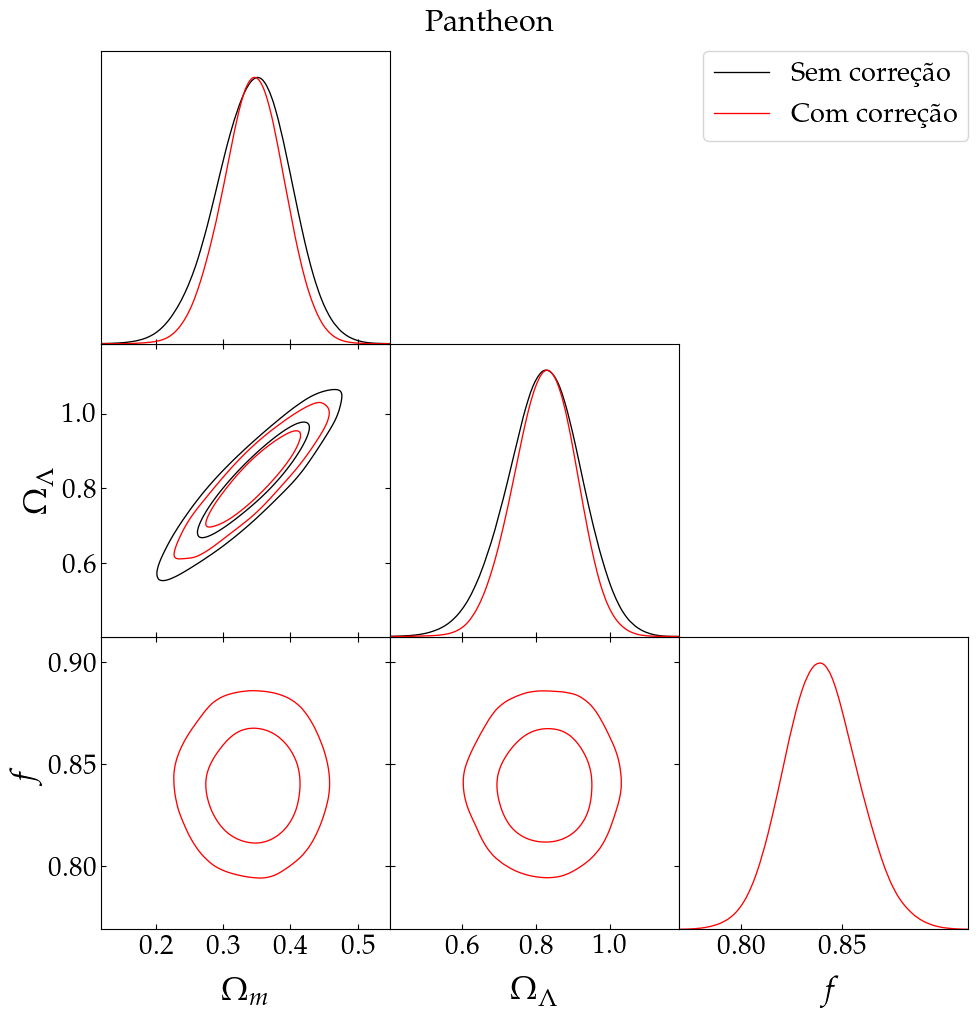

In [27]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamples1, gsamples], ('wm', 'wl', 'f'), filled=False,legend_labels=['Sem correção', 'Com correção'])
g.fig.suptitle(r"Pantheon", fontsize=22, y=1.02)
g.export('fig/Pantheon.pdf')
pl.show()

In [29]:
def insertDerived(sample, parnames, parlabel, num, gsample, derived, derivedName, derivedLabel):
    n = np.zeros(num)
    
    if derivedName not in parnames:
        newSample = np.c_[sample, derived]
        parnames.append(derivedName)
        gsample.addDerived(derived, name=derivedName, label=derivedLabel)
        
        return newSample, gsample, parnames, n

    elif derivedName in parnames:
        print('Parâmetro dependente já adicionado.')

        return sample, gsample, parnames, n

In [34]:
samplesf, gsamplesf, parnamesf, ndimf = insertDerived(samples, parnames, parlabels, 5, gsamples, 1/gsamples.getParams().f, 'f0', 'f_{0}')

Parâmetro dependente já adicionado.


In [47]:
MC_result(samplesf0, ndimf0, parnamesf0)

MCMC result:
H0 = 74.83018 +17.14699 +24.04560 -16.99022 -23.76043 (median: 74.64934, ml: 0.00000)
wm = 0.34477 +0.04587 +0.09009 -0.04576 -0.09439 (median: 0.34547, ml: 0.00000)
wl = 0.82289 +0.08403 +0.16400 -0.08514 -0.17357 (median: 0.82486, ml: 0.00000)
f = 0.83978 +0.01851 +0.03830 -0.01840 -0.03602 (median: 0.83953, ml: 0.00000)
f0 = 1.19136 +0.02609 +0.05279 -0.02626 -0.05252 (median: 1.19114, ml: 0.00000)


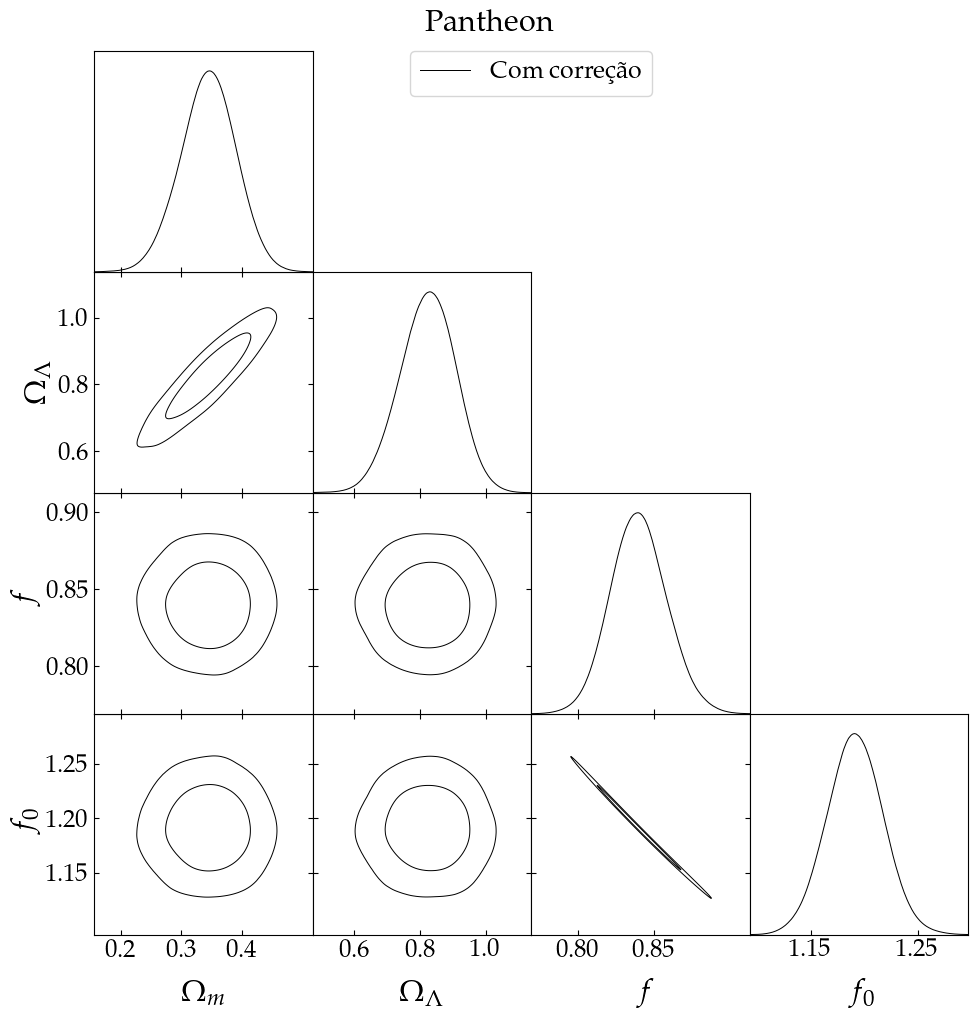

In [49]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesf0], ('wm', 'wl', 'f', 'f0'), filled=False,legend_labels=['Com correção'])
g.fig.suptitle(r"Pantheon", fontsize=22, y=1.02)
#g.export('fig/Pantheon-f.pdf')
pl.show()